<a href="https://colab.research.google.com/github/oliveirangel/projetos_pandas-python/blob/main/Projeto_Unicornios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

In [45]:
df_startup = pd.read_csv('unicorns till sep 2022.csv')

df_startup.shape

(1186, 7)

In [46]:
df_startup.head()

,Company,Valuation ($B),Date Joined,Country,City,Industry,Investors
0,ByteDance,$140,4/7/2017,China,Beijing,Artificial intelligence,"Sequoia Capital China, SIG Asia Investments, S..."
1,SpaceX,$127,12/1/2012,United States,Hawthorne,Other,"Founders Fund, Draper Fisher Jurvetson, Rothen..."
2,SHEIN,$100,7/3/2018,China,Shenzhen,E-commerce & direct-to-consumer,"Tiger Global Management, Sequoia Capital China..."
3,Stripe,$95,1/23/2014,United States,San Francisco,Fintech,"Khosla Ventures, LowercaseCapital, capitalG"
4,Canva,$40,1/8/2018,Australia,Surry Hills,Internet software & services,"Sequoia Capital China, Blackbird Ventures, Mat..."


In [47]:
df_startup.columns

Index(['Company', 'Valuation ($B)', 'Date Joined', 'Country', 'City ',
       'Industry', 'Investors'],
      dtype='object')

In [48]:
df_startup.rename(columns = {
    'Company' : 'Empresa',
    'Valuation ($B)' : 'Valor de Mercado ($)',
    'Date Joined' : 'Data de Adesão' ,
    'Country' : 'Pais',
    'City\xa0' : 'Cidade', # Usado caractere de espaço não separável
    'Industry' : 'Industria',
    'Investors' : 'Investimento'
}, inplace = True)

In [49]:
df_startup.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1186 entries, 0 to 1185
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Empresa               1186 non-null   object
 1   Valor de Mercado ($)  1186 non-null   object
 2   Data de Adesão        1186 non-null   object
 3   Pais                  1186 non-null   object
 4   Cidade                1186 non-null   object
 5   Industria             1186 non-null   object
 6   Investimento          1168 non-null   object
dtypes: object(7)
memory usage: 65.0+ KB


In [50]:
df_startup.isnull().sum()

,0
Empresa,0
Valor de Mercado ($),0
Data de Adesão,0
Pais,0
Cidade,0
Industria,0
Investimento,18


In [51]:
df_startup['Data de Adesão'] = pd.to_datetime(df_startup['Data de Adesão'])
df_startup.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1186 entries, 0 to 1185
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Empresa               1186 non-null   object        
 1   Valor de Mercado ($)  1186 non-null   object        
 2   Data de Adesão        1186 non-null   datetime64[ns]
 3   Pais                  1186 non-null   object        
 4   Cidade                1186 non-null   object        
 5   Industria             1186 non-null   object        
 6   Investimento          1168 non-null   object        
dtypes: datetime64[ns](1), object(6)
memory usage: 65.0+ KB


### **Para converter um tipo para tipo datetime:**
df_startup['Data de Adesão'] = pd.to_datetime(df_startup['Data de Adesão'], format='%d/%m/%Y')

In [81]:
# O 'dt.strftime' só foi usado porque eu já tinha feito a conversão para datetime e ele serve exatamente para converter novamente para String
df_startup['Data de Adesão_com_format'] = pd.to_datetime(df_startup['Data de Adesão'].dt.strftime('%d/%m/%Y'), format='%d/%m/%Y')

In [53]:
df_startup.head(10)

,Empresa,Valor de Mercado ($),Data de Adesão,Pais,Cidade,Industria,Investimento,Data de Adesão_com_format
0,ByteDance,$140,2017-04-07,China,Beijing,Artificial intelligence,"Sequoia Capital China, SIG Asia Investments, S...",2017-04-07
1,SpaceX,$127,2012-12-01,United States,Hawthorne,Other,"Founders Fund, Draper Fisher Jurvetson, Rothen...",2012-12-01
2,SHEIN,$100,2018-07-03,China,Shenzhen,E-commerce & direct-to-consumer,"Tiger Global Management, Sequoia Capital China...",2018-07-03
3,Stripe,$95,2014-01-23,United States,San Francisco,Fintech,"Khosla Ventures, LowercaseCapital, capitalG",2014-01-23
4,Canva,$40,2018-01-08,Australia,Surry Hills,Internet software & services,"Sequoia Capital China, Blackbird Ventures, Mat...",2018-01-08
5,Checkout.com,$40,2019-05-02,United Kingdom,London,Fintech,"Tiger Global Management, Insight Partners, DST...",2019-05-02
6,Instacart,$39,2014-12-30,United States,San Francisco,"Supply chain, logistics, & delivery","Khosla Ventures, Kleiner Perkins Caufield & By...",2014-12-30
7,Databricks,$38,2019-02-05,United States,San Francisco,Data management & analytics,"Andreessen Horowitz, New Enterprise Associates...",2019-02-05
8,Revolut,$33,2018-04-26,United Kingdom,London,Fintech,"index Ventures, DST Global, Ribbit Capital",2018-04-26
9,Epic Games,$31.50,2018-10-26,United States,Cary,Other,"Tencent Holdings, KKR, Smash Ventures",2018-10-26


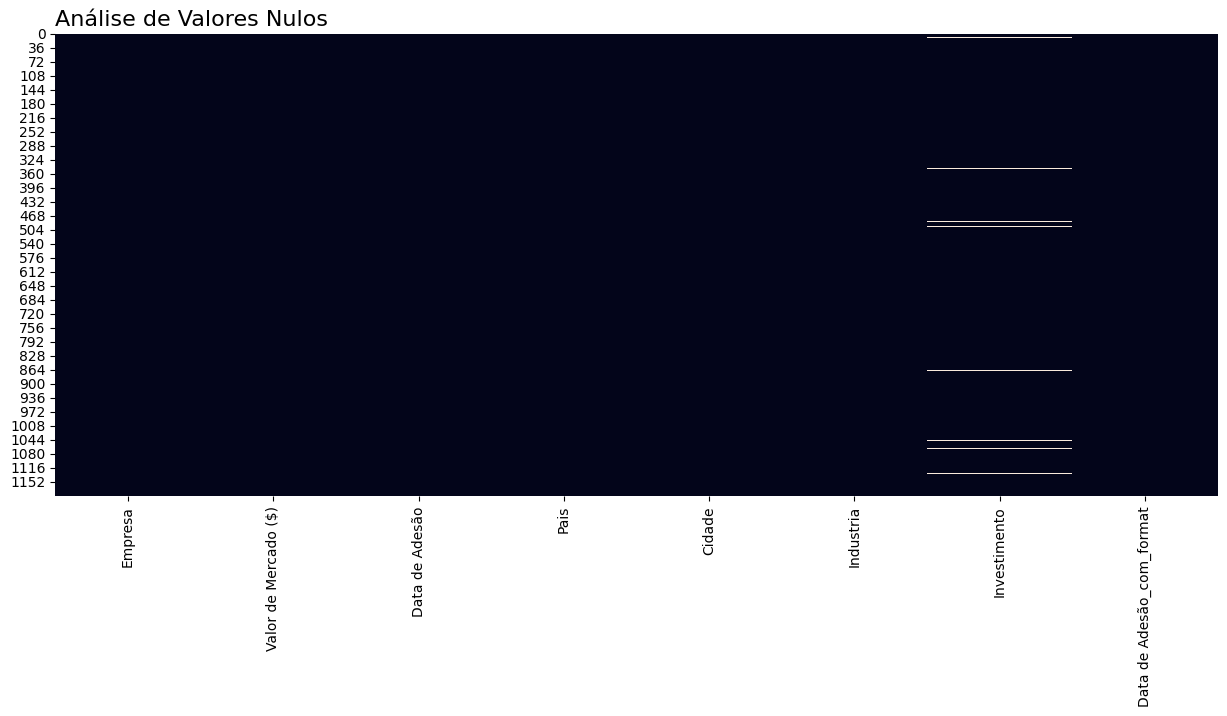

In [54]:
plt.figure(figsize=(15,6))
plt.title('Análise de Valores Nulos', fontsize= 16, loc= 'left')
sns.heatmap(df_startup.isnull(), cbar= False);
plt.xticks(fontsize= 10)
plt.yticks(fontsize= 10);

In [55]:
#Verifica os valores unicos da base de dados inteira
df_startup.nunique()

,0
Empresa,1183
Valor de Mercado ($),222
Data de Adesão,695
Pais,48
Cidade,286
Industria,34
Investimento,1152
Data de Adesão_com_format,695


In [56]:
#Verifica os valores unicos de uma determinada coluna
df_startup['Cidade'].unique()

array(['Beijing', 'Hawthorne', 'Shenzhen', 'San Francisco', 'Surry Hills',
       'London', 'Cary', 'Fintech', 'Jacksonville', 'Bengaluru',
       'Shanghai', 'Jakarta', 'Philadelphia', 'New York', 'Munich',
       'Waltham', 'San Diego', 'Roseville', 'Changsha', 'Istanbul',
       'Luohe', 'Cheung Sha Wan', 'Walpole', 'Victoria', 'Boston',
       'Glendale', 'Berlin', 'Stockholm', 'Kirkland', 'Gurugram',
       'Lerma de Villada', 'Mountain View', 'Fremont', 'Tallinn',
       'San Jose', 'San Mateo', 'Chicago', 'Mumbai', 'Irving',
       'Vancouver', 'Santa Clara', 'Pittsburgh', 'Palo Alto', 'Hangzhou',
       'Toronto', 'Changzhou', 'Amsterdam', 'Paris', 'Los Angeles',
       'Tel Aviv', 'Hoboken', 'Brooklyn', 'Helsinki', 'Pflugerville',
       'Oakland', 'Bogota', 'Brussels', 'Atlanta', 'Campinas',
       'Sao Paulo', 'Melbourne', 'Seoul', 'Gurgaon', 'Noida', 'Bellevue',
       'Montreal', 'Copenhagen', 'Geneva', 'Irvine', 'Burlingame',
       'Vilnius', 'Faridabad', 'Seattle', 'Gua

In [59]:
df_startup['Empresa'].value_counts(normalize = True) #gera os precentuais

,proportion
Empresa,
Bolt,0.001686
Fabric,0.001686
Branch,0.001686
Vectra Networks,0.000843
Cava Group,0.000843
...,...
WEMAKEPRICE,0.000843
Jobandtalent,0.000843
ManyPets,0.000843


In [58]:
df_startup['Cidade'].value_counts()

,count
Cidade,
San Francisco,168
New York,111
Beijing,62
Shanghai,46
London,36
...,...
Torrance,1
Kista,1
Morrisville,1


<BarContainer object of 34 artists>

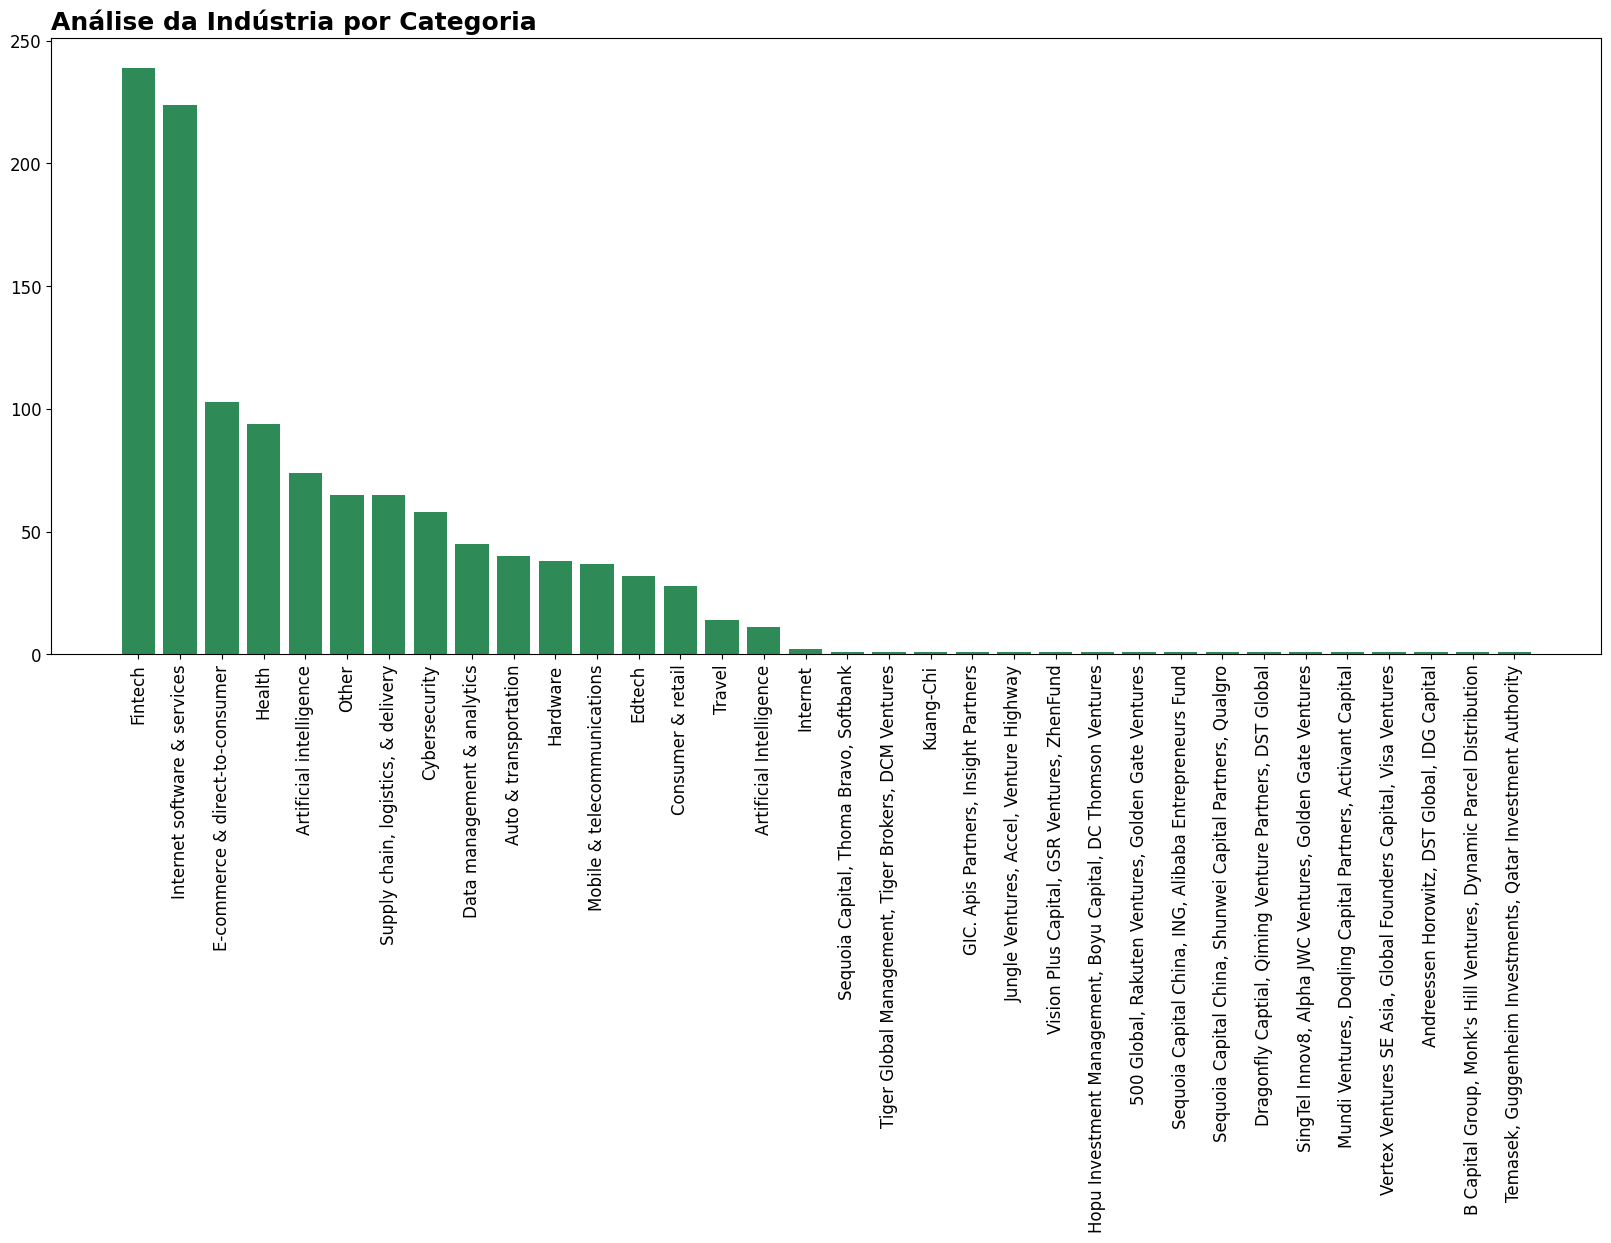

In [77]:
plt.figure(figsize= (20, 8))
plt.title('Análise da Indústria por Categoria', fontsize= 18, loc= 'left', fontweight = 'bold')
plt.xticks(rotation= 90, fontsize= 12)
plt.yticks(fontsize= 12)
plt.bar(df_startup['Industria'].value_counts().index, df_startup['Industria'].value_counts(), color = '#2E8B57')

In [78]:
df_startup['Pais'].value_counts()

,count
Pais,
United States,636
China,174
India,70
United Kingdom,46
Germany,29
France,24
Israel,22
Canada,19
Brazil,17


### **Round**
Serve para arredondar as casas decimais e o número ao final do código é o número de casas

In [82]:
Analise = round (df_startup['Pais'].value_counts (normalize = True) * 100, 1 ) #multiplica por 100 e deixa só uma casa depois da virgula

Analise

,proportion
Pais,
United States,53.6
China,14.7
India,5.9
United Kingdom,3.9
Germany,2.4
France,2.0
Israel,1.9
Canada,1.6
Brazil,1.4


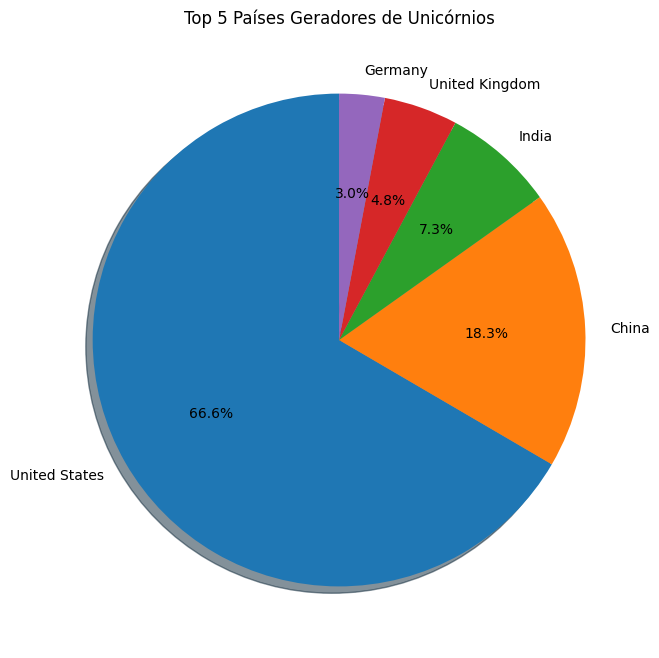

In [87]:
# Gráfico de Pizza
plt.figure(figsize = (10, 8))
plt.title('Top 5 Países Geradores de Unicórnios')
plt.pie(
    Analise.head(5),
    labels= Analise.index[0:5],
    shadow= True,
    startangle = 90,
    autopct= '%1.1f%%'
    );